In [60]:
from tensorflow.keras.datasets import cifar10

In [61]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [62]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [63]:
import torch

In [64]:
print(x_train.min(), x_train.max(), x_train.dtype)

0 255 uint8


In [65]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

In [66]:
print(x_train.min(), x_train.max(), x_train.dtype)

0.0 1.0 float32


In [67]:
x_train = torch.tensor(x_train).permute(0, 3, 1, 2)
y_train = torch.tensor(y_train).long().squeeze()

x_test = torch.tensor(x_test).permute(0, 3, 1, 2)
y_test = torch.tensor(y_test).long().squeeze()

In [68]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

torch.Size([50000, 3, 32, 32]) torch.Size([50000])
torch.Size([10000, 3, 32, 32]) torch.Size([10000])


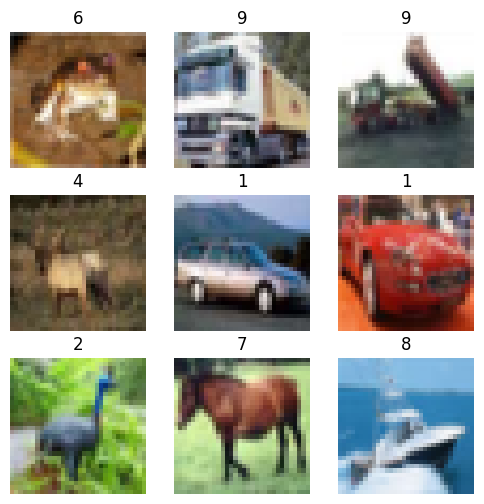

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].permute(1,2,0))
    plt.title(int(y_train[i]))
    plt.axis("off")
plt.show()

In [70]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(x_train, y_train)
test_dataset  = TensorDataset(x_test, y_test)

In [71]:
from torch.utils.data import DataLoader
batch_size = 64  # 4GB GPU pe safe

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [72]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape, images.dtype, labels.dtype)

torch.Size([64, 3, 32, 32]) torch.Size([64]) torch.float32 torch.int64


In [73]:
import torch
print(torch.__version__)
print("torch.version.cuda =", torch.version.cuda)

2.8.0+cpu
torch.version.cuda = None


In [74]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

False
0
No GPU


In [75]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32->16

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16->8

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), 
            nn.ReLU(),
            nn.MaxPool2d(2),  # 8->4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), 
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN()

In [87]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr = 3e-5, weight_decay=5e-4)

In [88]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x, y

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x, y

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

In [89]:
train_losses, test_losses = [], []
train_accs, test_accs = [], []
best_acc = 0.0
epochs = 8
for ep in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    te_loss, te_acc = evaluate(model, test_loader)

    train_losses.append(tr_loss); test_losses.append(te_loss)
    train_accs.append(tr_acc);   test_accs.append(te_acc)
    print(f"Epoch {ep:02d} | Train loss {tr_loss:.4f} acc {tr_acc:.4f} | Test loss {te_loss:.4f} acc {te_acc:.4f}")

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved!")

Epoch 01 | Train loss 0.9164 acc 0.8570 | Test loss 0.9613 acc 0.8137
✅ Best model saved!
Epoch 02 | Train loss 0.8878 acc 0.8715 | Test loss 0.9553 acc 0.8151
✅ Best model saved!
Epoch 03 | Train loss 0.8757 acc 0.8783 | Test loss 0.9501 acc 0.8182
✅ Best model saved!
Epoch 04 | Train loss 0.8645 acc 0.8835 | Test loss 0.9461 acc 0.8201
✅ Best model saved!
Epoch 05 | Train loss 0.8538 acc 0.8882 | Test loss 0.9443 acc 0.8205
✅ Best model saved!
Epoch 06 | Train loss 0.8458 acc 0.8919 | Test loss 0.9426 acc 0.8212
✅ Best model saved!
Epoch 07 | Train loss 0.8381 acc 0.8960 | Test loss 0.9406 acc 0.8244
✅ Best model saved!
Epoch 08 | Train loss 0.8308 acc 0.8991 | Test loss 0.9408 acc 0.8229


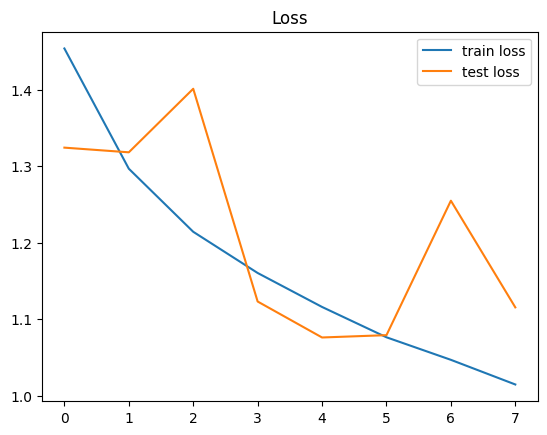

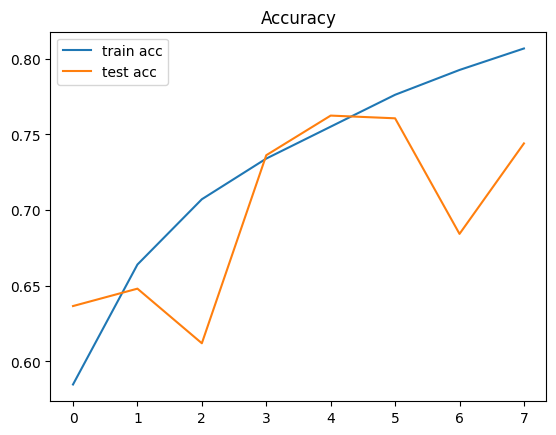

In [86]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="train loss")
plt.plot(test_losses, label="test loss")
plt.legend(); plt.title("Loss"); plt.show()

plt.figure()
plt.plot(train_accs, label="train acc")
plt.plot(test_accs, label="test acc")
plt.legend(); plt.title("Accuracy"); plt.show()

In [93]:
best_path = "best_model.pth"

# new fresh model object (same architecture)
best_model = SimpleCNN()
best_model.load_state_dict(torch.load(best_path))
best_model.eval()

best_test_acc = evaluate(best_model, test_loader)  # tumhara evaluate fn
print("Best checkpoint test acc:", best_test_acc)

Best checkpoint test acc: (0.940560341835022, 0.8244)
